<center>
    <h1></h1>
    <h1><b>OCES 5303</b></h1>
    <h2>Extended Project</h2>
    <hr>
    <p>Jonas Mathisrud Sterud</p>
    <p>21335836</p>
</center>

## Configuration

In [2]:
## Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
import torch
import cv2
import pickle
import random
import operator
import os

from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold, train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, matthews_corrcoef, make_scorer, ConfusionMatrixDisplay
from datetime import datetime
import cartopy.crs as ccrs
from torch import nn
from torch.utils.data import WeightedRandomSampler, DataLoader
from skorch import NeuralNetClassifier
from sklearn.utils.class_weight import compute_class_weight
from skorch.callbacks import LRScheduler
from torch.optim.lr_scheduler import CosineAnnealingLR


## Configuration

seed = int(11111)
_ = random.seed(seed)
_ = np.random.seed(seed)
_ = torch.manual_seed(seed)
_ = torch.backends.cudnn.deterministic = True
_ = torch.backends.cudnn.benchmark = False

## Mode

RE_RENDER = False

## Colors
## Colors

RED = "#FF6200"
RED_TRANSPARENT = "#FF6200A7"
GREEN = "#00B755"
GREEN_TRANSPARENT = "#00B755A7"
BLUE = "#0048FF"
BLUE_TRANSPARENT = "#0048FFA7"
GREY = "#959595"
GREY_TRANSPARENT = "#959595A7"

# Load and Parse

In [3]:
TRAIN_PNG_DIR = "./data/TRAIN_png/TRAIN_png"
TEST_PNG_DIR = "./data/TEST_png/TEST_png"
LABELS_TRAIN_DIR = "./data/LABELS_TRAIN/train"
TRAIN_IMAGES_PKL_DIR = "./data/train_images_pkl"
TEST_IMAGES_PKL_DIR = "./data/test_images_pkl"

# Load PKLs

def load_pkl(directory: str) -> dict:
    out = {}

    with os.scandir(directory) as dirs:
        for dir in dirs:
            date = datetime.strptime(dir.path.split("/")[-1], "%Y%m%d")

            with os.scandir(dir) as files:
                for file in files:
                    if file.is_file():
                        name = file.path.split("/")[-1].removesuffix(".pkl")
                        if (out.get(name) == None): out[name] = {}
                        #if (name == "eddy_centre"): # Only Eddy centres for now
                        with open(file.path, "rb") as rb_file:
                            try:
                                data = pickle.load(rb_file)
                                out[name][date] = data
                            except Exception as e:
                                print(e)
    
    return out

# Load labels
def load_labels(directory: str) -> dict:
    out = {}

    with os.scandir(directory) as files:
        for file in files:
            date = datetime.strptime(file.path.split("_")[-1].removesuffix(".csv"), "%Y%m%d")
            labels = pd.read_csv(file.path, header=None)

            out[date] = labels

    return out

# Load PNGs

def load_pngs(directory: str) -> pd.DataFrame:
    out = {}

    with os.scandir(directory) as files:
        for file in files:
            if file.is_file:
                (category, date, number) = file.path.split("/")[-1].removesuffix(".png").split("_")
                category = category
                date = datetime.strptime(date, "%Y%m%d")
                number = int(number)

                if out.get(category) == None:
                    out[category] = {}

                if out[category].get(date) == None:
                    out[category][date] = {}

                out[category][date][number] = cv2.imread(file.path, cv2.IMREAD_GRAYSCALE)

    for category in out.keys():
        for date in out[category].keys():
            out[category][date] = list(map(lambda kv: kv[1], sorted(out[category][date].items())))

    return pd.DataFrame(out)

# Load

df_png_train = load_pngs(TRAIN_PNG_DIR)

train_pkl_mapping = load_pkl(TRAIN_IMAGES_PKL_DIR)
train_labels_mapping = load_labels(LABELS_TRAIN_DIR)

df_png_test = load_pngs(TEST_PNG_DIR)
test_pkl_mapping = load_pkl(TEST_IMAGES_PKL_DIR)

# Format train PKLs

df_eddy_centre_train = pd.DataFrame(train_pkl_mapping["eddy_centre"].items()).set_index(0).rename(columns={ 1 : "EDDY_CENTRE"})
df_eddy_position_train = pd.DataFrame(train_pkl_mapping["eddy_position"].items()).set_index(0).rename(columns={ 1 : "EDDY_POSITION"})

df_eddy_latitude_train = pd.DataFrame(train_pkl_mapping["lat_contour_eddy"].items()).set_index(0).rename(columns={ 1 : "EDDY_LATITUDE" })
df_eddy_longitude_train = pd.DataFrame(train_pkl_mapping["lon_contour_eddy"].items()).set_index(0).rename(columns={ 1 : "EDDY_LONGITUDE" })

df_sst_latitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), train_pkl_mapping["lat_SST"].items())).set_index(0).rename(columns={ 1 : "SST_LATITUDE"})
df_sst_longitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), train_pkl_mapping["lon_SST"].items())).set_index(0).rename(columns={ 1 : "SST_LONGITUDE"})

df_chla_latitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), train_pkl_mapping["lat_CHLA"].items())).set_index(0).rename(columns={ 1 : "CHLA_LATITUDE"})
df_chla_longitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), train_pkl_mapping["lon_CHLA"].items())).set_index(0).rename(columns={ 1 : "CHLA_LONGITUDE"})

df_sla_latitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1[0], v0[1]))), train_pkl_mapping["lat_sealevel"].items())).set_index(0).rename(columns={ 1 : "SLA_LATITUDE"})
df_sla_longitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1[0], v0[1]))), train_pkl_mapping["lon_sealevel"].items())).set_index(0).rename(columns={ 1 : "SLA_LONGITUDE"})

df_labels_train = pd.DataFrame(map(lambda kv: (kv[0], kv[1].values.flatten()), train_labels_mapping.items())).set_index(0).rename(columns={ 1: "LABEL"})

# Format test PKLs

df_eddy_centre_test = pd.DataFrame(test_pkl_mapping["eddy_centre"].items()).set_index(0).rename(columns={ 1 : "EDDY_CENTRE"})
df_eddy_position_test = pd.DataFrame(test_pkl_mapping["eddy_position"].items()).set_index(0).rename(columns={ 1 : "EDDY_POSITION"})

df_eddy_latitude_test = pd.DataFrame(test_pkl_mapping["lat_contour_eddy"].items()).set_index(0).rename(columns={ 1 : "EDDY_LATITUDE" })
df_eddy_longitude_test = pd.DataFrame(test_pkl_mapping["lon_contour_eddy"].items()).set_index(0).rename(columns={ 1 : "EDDY_LONGITUDE" })

df_sst_latitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), test_pkl_mapping["lat_SST"].items())).set_index(0).rename(columns={ 1 : "SST_LATITUDE"})
df_sst_longitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), test_pkl_mapping["lon_SST"].items())).set_index(0).rename(columns={ 1 : "SST_LONGITUDE"})

df_chla_latitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), test_pkl_mapping["lat_CHLA"].items())).set_index(0).rename(columns={ 1 : "CHLA_LATITUDE"})
df_chla_longitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), test_pkl_mapping["lon_CHLA"].items())).set_index(0).rename(columns={ 1 : "CHLA_LONGITUDE"})

df_sla_latitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1[0], v0[1]))), test_pkl_mapping["lat_sealevel"].items())).set_index(0).rename(columns={ 1 : "SLA_LATITUDE"})
df_sla_longitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1[0], v0[1]))), test_pkl_mapping["lon_sealevel"].items())).set_index(0).rename(columns={ 1 : "SLA_LONGITUDE"})

df_labels_test = pd.DataFrame(map(lambda kv: (kv[0], kv[1]), test_pkl_mapping["eddy_labels"].items())).set_index(0).rename(columns={ 1: "LABEL"})

# Combine
frames_train = [df_png_train, df_eddy_centre_train, df_eddy_latitude_train, df_eddy_longitude_train, df_sst_latitude_train, df_sst_longitude_train, df_chla_latitude_train, df_chla_longitude_train, df_sla_latitude_train, df_sla_longitude_train, df_labels_train]
frames_test = [df_png_test, df_eddy_centre_test, df_eddy_latitude_test, df_eddy_longitude_test, df_sst_latitude_test, df_sst_longitude_test, df_chla_latitude_test, df_chla_longitude_test, df_sla_latitude_test, df_sla_longitude_test, df_labels_test]

df_train = pd.concat(frames_train, axis=1, sort=False)
df_test = pd.concat(frames_test, axis=1, sort=False)

unpickling stack underflow


In [4]:
df_train = df_train.explode(list(df_train.columns)).reset_index(names=["DATE"])
df_test = df_test.explode(list(df_test.columns)).reset_index(names=["DATE"])

#df_full = pd.concat([df_train, df_test])

X_train = df_train.drop(columns = ["LABEL"])
y_train = df_train[["LABEL"]]

X_test = df_train.drop(columns = ["LABEL"])
y_test = df_train[["LABEL"]]
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size = 0.5, random_state = seed)

Xy_train = pd.concat([X_train, y_train], axis=1)

# Various Information

In [5]:
# Date range

range_train = sorted(Xy_train["DATE"])
range_test = sorted(Xy_train["DATE"])

print(f"Train date range: From {range_train[0]} to {range_train[-1]}")
print(f"Test date range: From {range_test[0]} to {range_test[-1]}")

Train date range: From 2017-05-01 00:00:00 to 2017-06-04 00:00:00
Test date range: From 2017-05-01 00:00:00 to 2017-06-04 00:00:00


In [6]:
for i, procentage in enumerate(Xy_train.value_counts("LABEL") / len(Xy_train)):
    print(f"(Train) Class {i}: {procentage * 100:.2f} %")

(Train) Class 0: 38.15 %
(Train) Class 1: 32.76 %
(Train) Class 2: 29.10 %


<p>
We load two datasets - a training set and a test set.
</p>

<p>
The data in our training set is spread across 34 different dates from 2017, ranging from the 1st of May to the 4th of June. Each date contains between 103 and 184 observations, totalling 4842 total observations.
</p>

<p>
Our testing set, also contains data from 2017, spanning from the 5th of June to the 30th of June.
Here, each date have between 111 and 228 observations, totalling 4199 total observations.
</p>

# Category Differences

In [7]:
def visualize_images_with(Xy, label, save_as: str = None):
    fig, axs = plt.subplots(4, 4)
    fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=-0.55, hspace=0.1)

    selected_rows = Xy[Xy["LABEL"] == label]
    custom_i = { 0: [122, 129, 148, 137], 1: [157, 187, 169, 158], 2: [100, 121, 132, 124] }
    for i, ax in enumerate(axs.flat):
        ax.axis('off')

        index = custom_i[label][i % 4]
        match int(i / 4):
            case 0: ax.imshow(selected_rows["SST"].iloc[index], cmap=cmocean.cm.thermal)
            case 1: ax.imshow(selected_rows["CHLA"].iloc[index], cmap=cmocean.cm.algae)
            case 2: ax.imshow(selected_rows["SLA"].iloc[index], cmap=cmocean.cm.balance)
            case 3: ax.imshow(selected_rows["EDDY"].iloc[index], cmap=cmocean.cm.thermal)

    if (save_as != None):
        plt.savefig(f"./figures/{save_as}", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0)

    plt.show()


In [8]:
if RE_RENDER:
    visualize_images_with(Xy_train, 0, save_as="images_with_no_cyclone.png") # No eddy
    visualize_images_with(Xy_train, 1, save_as="images_with_cyclone.png") # Eddy
    visualize_images_with(Xy_train, 2, save_as="images_with_anticyclone.png") # Reverse eddy

# Map

In [9]:
# Print min/max lat/lon, used to center image
min_lat = np.round(min(map(lambda r: min(r), Xy_train["SST_LATITUDE"])))
max_lat = np.round(max(map(lambda r: max(r), Xy_train["SST_LATITUDE"])))
min_lon = np.round(min(map(lambda r: min(r), Xy_train["SST_LONGITUDE"])))
max_lon = np.round(max(map(lambda r: max(r), Xy_train["SST_LONGITUDE"])))

print(f"Min lat: {min_lat}\nMax lat: {max_lat}\nMin lon: {min_lon}\nMax lon: {max_lon}\n")

Min lat: 21.0
Max lat: 59.0
Min lon: 286.0
Max lon: 339.0



In [10]:
def images_on_map(Xy, categories: list[str], cm="viridis", alpha: list[float]=[0.8], mark_eddy_contour=False, mark_eddy_centre=False, limit: int = -1, save_as: str = None, vmin=None, vmax=None):
    plt.figure(figsize=(20, 10), )
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_global()
    ax.coastlines()

    # Images
    for j, category in enumerate(categories):
        for i, (_, row) in enumerate(Xy.iterrows()):
            if (limit >= 0 and i >= limit):
                break

            lats = [lat for lat in row[f"{category}_LATITUDE"]]
            lons = [lon for lon in row[f"{category}_LONGITUDE"]]
            lon2d, lat2d = np.meshgrid(lons, lats)

            ax.pcolormesh(
                lon2d,
                lat2d,
                row[category],
                transform=ccrs.PlateCarree(),
                cmap=cm,
                snap=True,
                alpha=alpha[j],
                shading="auto",
                vmin=vmin,
                vmax=vmax,
            )

            # Mark eddy contour
            if (mark_eddy_contour):
                if (not np.any(np.isnan(row["EDDY_LATITUDE"])) and not np.any(np.isnan(row["EDDY_LONGITUDE"]))):
                    ax.scatter(row["EDDY_LONGITUDE"], row["EDDY_LATITUDE"], color=(1, 0, 0, 0.05), s=1, transform=ccrs.PlateCarree(), zorder=5)
                
            # Mark eddy centre
            if (mark_eddy_centre):
                if (not np.any(np.isnan(row["EDDY_CENTRE"]))):
                    ax.scatter(row["EDDY_CENTRE"][0], row["EDDY_CENTRE"][1], color=(1, 0, 0, 0.5), s=1.0, transform=ccrs.PlateCarree(), zorder=5)

    zoom = 3
    ax.set_extent([
        286 - zoom, 339 + zoom,
        21 - zoom, 59 + zoom
    ], crs=ccrs.PlateCarree())

    if (save_as != None):
        plt.savefig(f"./figures/{save_as}", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0)
    plt.show()

In [11]:
if RE_RENDER:
    images_on_map(Xy_train, ["SST"], cm=cmocean.cm.thermal, alpha=[0.85], mark_eddy_centre=True, mark_eddy_contour=False, limit=-1, vmin=0, vmax=255, save_as="sst_map_train.png")

In [12]:
if RE_RENDER:
    images_on_map(Xy_train, ["CHLA"], cm=cmocean.cm.algae, alpha=[0.85], mark_eddy_centre=True, mark_eddy_contour=False, limit=-1, vmin=0, vmax=255, save_as="chla_map_train.png")

# Specify Features

In [13]:
X_train = X_train[["SST", "CHLA"]]
X_val = X_val[["SST", "CHLA"]]
X_test = X_test[["SST", "CHLA"]]

# Transformers

In [14]:
# Transformer: flip images

def _orientate(data):
    data_c = data.copy()

    for category in data_c.columns:
        if (category in ["SST", "SST_LATITUDE"]):
            data_c[category] = data_c[category].map(lambda matrix: np.flipud(matrix))

    return data_c

t_orientate = FunctionTransformer(func=_orientate)

In [15]:
# Transformer: remove corrupt images (pixel sums above 94%)

def _factor_sst(img, scaler):
    return np.sum(np.abs(scaler.transform(img.reshape(-1, 1))))

scaler_sst = MinMaxScaler(feature_range=(-1, 1)).fit(np.concatenate(X_train["SST"].map(lambda img: img.flatten()).values).reshape(-1, 1))
sorted_sums_sst = sorted([_factor_sst(img, scaler_sst) for img in X_train["SST"].tolist()])
limit_sst = sorted_sums_sst[int(len(sorted_sums_sst) * 0.94)]

def _filter_sst(data):
    data_c = data.copy()

    remove = data_c[data_c["SST"].map(lambda img: _factor_sst(img, scaler_sst)) > limit_sst].index.values
    data_c = data_c.drop(remove)

    return data_c

t_filter_sst = FunctionTransformer(func=_filter_sst)

In [16]:
# Transformer: mask corrupt images (pixel sums above 94%)

def _factor_sst(img, scaler):
    return np.sum(np.abs(scaler.transform(img.reshape(-1, 1))))

scaler_sst = MinMaxScaler(feature_range=(-1, 1)).fit(np.concatenate(X_train["SST"].map(lambda img: img.flatten()).values).reshape(-1, 1))
sorted_sums_sst = sorted([_factor_sst(img, scaler_sst) for img in X_train["SST"].tolist()])
limit_sst = sorted_sums_sst[int(len(sorted_sums_sst) * 0.94)]

def _mask_sst(data):
    data_c = data.copy()

    tags = data_c[data_c["SST"].map(lambda img: _factor_sst(img, scaler_sst)) > limit_sst].index.values
    for tag in tags: data_c.at[tag, "SST"] = np.full(data_c.loc[tag, "SST"].shape, 255, dtype="uint8")

    return data_c

t_mask_sst = FunctionTransformer(func=_mask_sst)

In [17]:
# Transformer: tag corrupt images (pixel sums above 94%)

def _factor_sst(img, scaler):
    return np.sum(np.abs(scaler.transform(img.reshape(-1, 1))))

scaler_sst = MinMaxScaler(feature_range=(-1, 1)).fit(np.concatenate(X_train["SST"].map(lambda img: img.flatten()).values).reshape(-1, 1))
sorted_sums_sst = sorted([_factor_sst(img, scaler_sst) for img in X_train["SST"].tolist()])
limit_sst = sorted_sums_sst[int(len(sorted_sums_sst) * 0.94)]

def _tag_sst(data):
    data_c = data.copy()
    data_c["SST_TAG"] = data_c["SST"]

    tags = data_c[data_c["SST"].map(lambda img: _factor_sst(img, scaler_sst)) > limit_sst].index.values
    for tag in tags: data_c.at[tag, "SST_TAG"] = np.zeros(data_c.loc[tag, "SST_TAG"].shape, dtype="uint8")
    for tag in set(data_c.index.values) - set(tags): data_c.at[tag, "SST_TAG"] = np.ones(data_c.loc[tag, "SST_TAG"].shape, dtype="uint8")

    return data_c

t_tag_sst = FunctionTransformer(func=_tag_sst)

In [18]:
# Transformer: mask corrupt images (pixel sums above 8%)

def _factor_chla(img, scaler):
    return np.sum(scaler.transform(img.reshape(-1, 1)))

scaler_chla = MinMaxScaler(feature_range=(0, 1)).fit(np.concatenate(X_train["CHLA"].map(lambda img: img.flatten()).values).reshape(-1, 1))
sorted_sums_chla = sorted([_factor_chla(img, scaler_chla) for img in X_train["CHLA"].tolist()])
limit_chla = sorted_sums_chla[int(len(sorted_sums_chla) * 0.08)]

def _mask_chla(data):
    data_c = data.copy()

    tags = data_c[data_c["CHLA"].map(lambda img: _factor_chla(img, scaler_chla)) <= limit_chla].index.values
    for tag in tags: data_c.at[tag, "CHLA"] = np.full(data_c.loc[tag, "CHLA"].shape, 255, dtype="uint8")

    return data_c

t_mask_chla = FunctionTransformer(func=_mask_chla)

In [19]:
# Transformer: tag corrupt images (pixel sums above 8%)

def _factor_chla(img, scaler):
    return np.sum(scaler.transform(img.reshape(-1, 1)))

scaler_chla = MinMaxScaler(feature_range=(0, 1)).fit(np.concatenate(X_train["CHLA"].map(lambda img: img.flatten()).values).reshape(-1, 1))
sorted_sums_chla = sorted([_factor_chla(img, scaler_chla) for img in X_train["CHLA"].tolist()])
limit_chla = sorted_sums_chla[int(len(sorted_sums_chla) * 0.08)]

def _tag_chla(data):
    data_c = data.copy()
    data_c["CHLA_TAG"] = data_c["CHLA"]

    tags = data_c[data_c["CHLA"].map(lambda img: _factor_chla(img, scaler_chla)) <= limit_chla].index.values
    for tag in tags: data_c.at[tag, "CHLA_TAG"] = np.zeros(data_c.loc[tag, "CHLA_TAG"].shape, dtype="uint8")
    for tag in set(data_c.index.values) - set(tags): data_c.at[tag, "CHLA_TAG"] = np.ones(data_c.loc[tag, "CHLA_TAG"].shape, dtype="uint8")

    return data_c

t_tag_chla = FunctionTransformer(func=_tag_chla)

In [20]:
# Transformer: resize images

def _crop(img, bounding): # https://stackoverflow.com/a/50322574
    start = tuple(map(lambda a, da: a//2-da//2, img.shape, bounding))
    end = tuple(map(operator.add, start, bounding))
    slices = tuple(map(slice, start, end))

    return img[slices]

def _resize(data):
    data_c = data.copy()

    min_size = min(np.concatenate(list(map(lambda a: list(map(lambda b: b.shape, a)), data.values))).flatten())
    min_shape = (min_size, min_size)

    for category in data_c.columns:
        data_c[category] = data_c[category].map(lambda img: _crop(img, min_shape))

    return data_c

t_resize = FunctionTransformer(func=_resize)

In [21]:
# Transformer: scale images

scalers = {}
for category in X_train.columns:
    scalers[category] = StandardScaler().fit(np.concatenate(X_train[category].map(lambda img: img.flatten()).values).reshape(-1, 1))

def _scale_image(img, scaler):
    shape = img.shape
    scaled = scaler.transform(img.reshape(-1, 1))

    return scaled.reshape(shape)
    

def _scale(data):
    data_c = data.copy()

    for category in data_c.columns:
        scaler = scalers.get(category)
        if (scaler == None): scaler = scalers["SST"] # Fallback (for mask)

        if (category in ["SST", "CHLA"]):
            data_c[category] = data_c[category].map(lambda img: _scale_image(img, scaler))

    return data_c

t_scale = FunctionTransformer(func=_scale)

In [22]:
# Transformer: into tensors

# Shape = (Sample, Channel, Height, Width)
def _add_tensors_x(data):
    data_c = data.copy()

    stacks = []
    for column in data_c.columns:
        stacked = np.stack(data_c[column].values)  # (N, H, W)
        stacks.append(stacked)

    # Stack (C, N, H, W)
    data_c = np.stack(stacks, axis=0)

    # Rearrange (N, C, H, W)
    data_c = np.transpose(data_c, (1, 0, 2, 3))
    data_c = torch.from_numpy(data_c).float()

    return data_c

t_tensors_x = FunctionTransformer(func=_add_tensors_x)

In [23]:
# Assumes LABEL
def _add_tensors_y(data):
    data_c = data.copy()

    flattened = [arr for arr in data_c["LABEL"]]
    data_c = torch.tensor(flattened, dtype=torch.long)

    return data_c

t_tensors_y = FunctionTransformer(func=_add_tensors_y)

In [24]:
if RE_RENDER:
    df_filtered = t_filter_sst.transform(X_train)

    images_on_map(df_train.loc[df_filtered.index], ["SST"], cm=cmocean.cm.thermal, alpha=[0.85], mark_eddy_centre=True, mark_eddy_contour=False, limit=-1, vmin=0, vmax=255, save_as="sst_map_train_filtered_in.png")
    images_on_map(df_train.loc[list(set(df_train.index.values) - set(df_filtered.index.values))], ["SST"], cm=cmocean.cm.thermal, alpha=[0.85], mark_eddy_centre=True, mark_eddy_contour=False, limit=-1, vmin=0, vmax=255, save_as="sst_map_train_filtered_out.png")

In [25]:
if RE_RENDER:
    df_masked = t_mask_chla.transform(X_train)

    df_masked_y = df_masked[df_masked["CHLA"].apply(lambda matrix: np.all(matrix))]
    df_masked_n = df_masked.loc[list(set(df_masked.index.values) - set(df_masked_y.index.values))]

    print(f"Masked: {len(df_masked_y)}")
    print(f"Unmasked: {len(df_masked_n)}")

    images_on_map(df_train.loc[df_masked_y.index], ["CHLA"], cm=cmocean.cm.algae, alpha=[0.85], mark_eddy_centre=True, mark_eddy_contour=False, limit=-1, vmin=0, vmax=255, save_as="chla_map_train_filtered_in.png")
    images_on_map(df_train.loc[df_masked_n.index], ["CHLA"], cm=cmocean.cm.algae, alpha=[0.85], mark_eddy_centre=True, mark_eddy_contour=False, limit=-1, vmin=0, vmax=255, save_as="chla_map_train_filtered_out.png")

In [26]:
if RE_RENDER:
    imgs_before = X_train.iloc[111]
    imgs_after = t_orientate.transform(X_train).iloc[111]

    plt.imshow(imgs_before["SST"], cmap=cmocean.cm.thermal, vmin=0, vmax=255)
    plt.axis('off')
    plt.savefig(f"./figures/sst_before_flip.png", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0)
    plt.show()

    plt.imshow(imgs_after["SST"], cmap=cmocean.cm.thermal, vmin=0, vmax=255)
    plt.axis('off')
    plt.savefig(f"./figures/sst_after_flip.png", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0)
    plt.show()

    plt.imshow(imgs_before["CHLA"], cmap=cmocean.cm.algae, vmin=0, vmax=255)
    plt.axis('off')
    plt.savefig(f"./figures/chla_before_flip.png", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0)
    plt.show()

    plt.imshow(imgs_after["CHLA"], cmap=cmocean.cm.algae, vmin=0, vmax=255)
    plt.axis('off')
    plt.savefig(f"./figures/chla_after_flip.png", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0)
    plt.show()

# Convolution Neural Network

In [ ]:
class CNN(nn.Module):
    def __init__(self, in_channels):
        super(CNN, self).__init__()

        self.cls = nn.Sequential(
            nn.Sequential(
                nn.Conv2d(in_channels, 16, kernel_size=3, padding="same", bias=False),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
            ),

            nn.Sequential(
                nn.Conv2d(16, 32, kernel_size=3, padding="same", bias=False),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
            ),

            nn.Conv2d(32, 64, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fc1 = nn.Sequential(
            nn.Linear(64, 32, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.65),
        )

        self.fc2 = nn.Sequential(
            nn.Linear(32, 3),
        )

    def forward(self, x):
        x = self.cls(x)
        x = x.view(x.shape[0], -1)
        
        x = self.fc1(x)
        x = self.fc2(x)

        return x

<h1>Pipelines</h1>

In [28]:
# TODO TEMP START
EPOCHS = 30

weight = torch.tensor(compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train.values.flatten()
), dtype=torch.float)

pipeline_5 = Pipeline([
    ("mask_chla", t_mask_chla),
    ("orientate", t_orientate),
    ("scale", t_scale),
    ("resize", t_resize),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(2),
        criterion=nn.CrossEntropyLoss(weight=weight),
        optimizer=torch.optim.AdamW,
        lr=1e-2,
        optimizer__weight_decay=2e-3, # L2
        max_epochs=EPOCHS,
        iterator_train__shuffle=True,
        verbose=10,
        callbacks=[LRScheduler(policy=CosineAnnealingLR, T_max=EPOCHS, eta_min=1e-4)]
    )),
])

filter_index = t_filter_sst.transform(X_train).index

pipeline_5.fit(
    X_train.drop(index=X_train.index.difference(filter_index)),
    t_tensors_y.transform(y_train.drop(index=y_train.index.difference(filter_index)))
)

pipelines = [pipeline_5]

# TODO TEMP END

torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64, 1, 1])
torch.Size([128, 64, 8, 8])
torch.Size([128, 64,

In [ ]:
## Could of course do a grid search instead.

# Constants
EPOCHS = 30

# Weights

weight = torch.tensor(compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train.values.flatten()
), dtype=torch.float)

# Default

pipeline_1 = Pipeline([
    ("orientate", t_orientate),
    ("scale", t_scale),
    ("resize", t_resize),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(2),
        criterion=nn.CrossEntropyLoss(weight=weight),
        optimizer=torch.optim.AdamW,
        lr=1e-2,
        optimizer__weight_decay=2e-3, # L2
        max_epochs=EPOCHS,
        iterator_train__shuffle=True,
        verbose=10,
        callbacks=[LRScheduler(policy=CosineAnnealingLR, T_max=EPOCHS, eta_min=1e-4)]
    )),
])

pipeline_1.fit(
    X_train,
    t_tensors_y.transform(y_train)
)

# Remove SST

pipeline_2 = Pipeline([
    ("orientate", t_orientate),
    ("scale", t_scale),
    ("resize", t_resize),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(2),
        criterion=nn.CrossEntropyLoss(weight=weight),
        optimizer=torch.optim.AdamW,
        lr=1e-2,
        optimizer__weight_decay=2e-3, # L2
        max_epochs=EPOCHS,
        iterator_train__shuffle=True,
        verbose=10,
        callbacks=[LRScheduler(policy=CosineAnnealingLR, T_max=EPOCHS, eta_min=1e-4)]
    )),
])

filter_index = t_filter_sst.transform(X_train).index

pipeline_2.fit(
    X_train.drop(index=X_train.index.difference(filter_index)),
    t_tensors_y.transform(y_train.drop(index=y_train.index.difference(filter_index)))
)

# Mask SST

pipeline_3 = Pipeline([
    ("mask_sst", t_mask_sst),
    ("orientate", t_orientate),
    ("scale", t_scale),
    ("resize", t_resize),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(2),
        criterion=nn.CrossEntropyLoss(weight=weight),
        optimizer=torch.optim.AdamW,
        lr=1e-2,
        optimizer__weight_decay=2e-3, # L2
        max_epochs=EPOCHS,
        iterator_train__shuffle=True,
        verbose=10,
        callbacks=[LRScheduler(policy=CosineAnnealingLR, T_max=EPOCHS, eta_min=1e-4)]
    )),
])

pipeline_3.fit(
    X_train,
    t_tensors_y.transform(y_train)
)

# Tag SST

pipeline_4 = Pipeline([
    ("tag_sst", t_tag_sst),
    ("orientate", t_orientate),
    ("scale", t_scale),
    ("resize", t_resize),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(3),
        criterion=nn.CrossEntropyLoss(weight=weight),
        optimizer=torch.optim.AdamW,
        lr=1e-2,
        optimizer__weight_decay=2e-3, # L2
        max_epochs=EPOCHS,
        iterator_train__shuffle=True,
        verbose=10,
        callbacks=[LRScheduler(policy=CosineAnnealingLR, T_max=EPOCHS, eta_min=1e-4)]
    )),
])

pipeline_4.fit(
    X_train,
    t_tensors_y.transform(y_train)
)

# Remove SST, mask CHLA

pipeline_5 = Pipeline([
    ("mask_chla", t_mask_chla),
    ("orientate", t_orientate),
    ("scale", t_scale),
    ("resize", t_resize),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(2),
        criterion=nn.CrossEntropyLoss(weight=weight),
        optimizer=torch.optim.AdamW,
        lr=1e-2,
        optimizer__weight_decay=2e-3, # L2
        max_epochs=EPOCHS,
        iterator_train__shuffle=True,
        verbose=10,
        callbacks=[LRScheduler(policy=CosineAnnealingLR, T_max=EPOCHS, eta_min=1e-4)]
    )),
])

filter_index = t_filter_sst.transform(X_train).index

pipeline_5.fit(
    X_train.drop(index=X_train.index.difference(filter_index)),
    t_tensors_y.transform(y_train.drop(index=y_train.index.difference(filter_index)))
)

# Remove SST, tag CHLA

pipeline_6 = Pipeline([
    ("tag_chla", t_tag_chla),
    ("orientate", t_orientate),
    ("scale", t_scale),
    ("resize", t_resize),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(3),
        criterion=nn.CrossEntropyLoss(weight=weight),
        optimizer=torch.optim.AdamW,
        lr=1e-2,
        optimizer__weight_decay=2e-3, # L2
        max_epochs=EPOCHS,
        iterator_train__shuffle=True,
        verbose=10,
        callbacks=[LRScheduler(policy=CosineAnnealingLR, T_max=EPOCHS, eta_min=1e-4)]
    )),
])

filter_index = t_filter_sst.transform(X_train).index

pipeline_6.fit(
    X_train.drop(index=X_train.index.difference(filter_index)),
    t_tensors_y.transform(y_train.drop(index=y_train.index.difference(filter_index)))
)

# Mask SST, mask CHLA

pipeline_7 = Pipeline([
    ("mask_sst", t_mask_sst),
    ("mask_chla", t_mask_chla),
    ("orientate", t_orientate),
    ("scale", t_scale),
    ("resize", t_resize),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(2),
        criterion=nn.CrossEntropyLoss(weight=weight),
        optimizer=torch.optim.AdamW,
        lr=1e-2,
        optimizer__weight_decay=2e-3, # L2
        max_epochs=EPOCHS,
        iterator_train__shuffle=True,
        verbose=10,
        callbacks=[LRScheduler(policy=CosineAnnealingLR, T_max=EPOCHS, eta_min=1e-4)]
    )),
])

pipeline_7.fit(
    X_train,
    t_tensors_y.transform(y_train)
)

# Mask SST, tag CHLA

pipeline_8 = Pipeline([
    ("mask_sst", t_mask_sst),
    ("tag_chla", t_tag_chla),
    ("orientate", t_orientate),
    ("scale", t_scale),
    ("resize", t_resize),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(3),
        criterion=nn.CrossEntropyLoss(weight=weight),
        optimizer=torch.optim.AdamW,
        lr=1e-2,
        optimizer__weight_decay=2e-3, # L2
        max_epochs=EPOCHS,
        iterator_train__shuffle=True,
        verbose=10,
        callbacks=[LRScheduler(policy=CosineAnnealingLR, T_max=EPOCHS, eta_min=1e-4)]
    )),
])

pipeline_8.fit(
    X_train,
    t_tensors_y.transform(y_train)
)

# Tag SST, mask CHLA

pipeline_9 = Pipeline([
    ("tag_sst", t_tag_sst),
    ("mask_chla", t_mask_chla),
    ("orientate", t_orientate),
    ("scale", t_scale),
    ("resize", t_resize),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(3),
        criterion=nn.CrossEntropyLoss(weight=weight),
        optimizer=torch.optim.AdamW,
        lr=1e-2,
        optimizer__weight_decay=2e-3, # L2
        max_epochs=EPOCHS,
        iterator_train__shuffle=True,
        verbose=10,
        callbacks=[LRScheduler(policy=CosineAnnealingLR, T_max=EPOCHS, eta_min=1e-4)]
    )),
])

pipeline_9.fit(
    X_train,
    t_tensors_y.transform(y_train)
)

# Tag SST, tag CHLA

pipeline_10 = Pipeline([
    ("tag_sst", t_tag_sst),
    ("tag_chla", t_tag_chla),
    ("orientate", t_orientate),
    ("scale", t_scale),
    ("resize", t_resize),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(4),
        criterion=nn.CrossEntropyLoss(weight=weight),
        optimizer=torch.optim.AdamW,
        lr=1e-2,
        optimizer__weight_decay=2e-3, # L2
        max_epochs=EPOCHS,
        iterator_train__shuffle=True,
        verbose=10,
        callbacks=[LRScheduler(policy=CosineAnnealingLR, T_max=EPOCHS, eta_min=1e-4)]
    )),
])

pipeline_10.fit(
    X_train,
    t_tensors_y.transform(y_train)
)

# Collect

pipelines = [
    pipeline_1,
    pipeline_2,
    pipeline_3,
    pipeline_4,
    pipeline_5,
    pipeline_6,
    pipeline_7,
    pipeline_8,
    pipeline_9,
    pipeline_10,
]

  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.1237       0.4365        1.0949  0.0100  1.6538
      2        1.0780       0.4448        1.0649  0.0100  1.9220
      3        1.0626       0.4778        1.0531  0.0099  2.0376
      4        1.0639       0.4510        1.0511  0.0098  2.1155
      5        1.0447       0.4768        1.0371  0.0096  2.1178
      6        1.0410       0.4995        1.0332  0.0093  2.0651
      7        1.0275       0.5150        1.0042  0.0091  2.1722
      8        1.0076       0.4107        1.1134  0.0087  2.0755
      9        1.0021       0.4840        1.0356  0.0084  1.9975
     10        0.9811       0.4561        1.0413  0.0080  2.1887
     11        0.9885       0.5212        0.9874  0.0075  2.0346
     12        0.9686       0.5335        0.9619  0.0071  2.0022
     13        0.9496       0.5614        0.9381  0.0066  1.9025
     14        0.9331    

# Metrics

In [31]:
class Metrics:
    def __init__(self, model, X, y):
        self.measurements = [
            ["Accuracy", accuracy_score],
            ["Balanced accuracy", balanced_accuracy_score],
            ["Matthews correlation coefficient", matthews_corrcoef]
        ]

        self._metrics = list(map(lambda kv: (
            kv[0],
            kv[1](y, model.predict(X))
        ), self.measurements))

    def __repr__(self):
        return '\n'.join(map(lambda kv: f"{kv[0]}: {np.abs(kv[1]):.5f}", self._metrics))

In [32]:
# Calculate metrics for all pipelines, and sort

metrics_list = list(map(lambda tuple: (tuple[0] + 1, tuple[1], Metrics(tuple[1], X_val, list(map(lambda v: v[0], y_val.values)))), enumerate(pipelines)))
metrics_sorted = sorted(metrics_list, key=lambda v: v[2]._metrics[1][1], reverse=True)[0]

In [33]:
print(f"Best pipeline: {metrics_sorted[0]}")
print(f"{metrics_sorted[2]}")

Best pipeline: 1
Accuracy: 0.70756
Balanced accuracy: 0.70435
Matthews correlation coefficient: 0.56102


# Loss

In [34]:
def visualize_loss(pipeline, save_as=None):
    df_loss = pd.DataFrame(
        list(map(lambda v: [v["epoch"], v["train_loss"], v["valid_loss"]], pipeline.steps[-1][1].history[0:-2]))
    ).rename(columns={ 0: "Epoch", 1: "Training loss", 2: "Validation loss"})

    plt.subplots(figsize=(10, 5))
    plt.plot(df_loss["Epoch"], df_loss["Training loss"], c=RED, label="Training loss")
    plt.plot(df_loss["Epoch"], df_loss["Validation loss"], c=BLUE, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    if (save_as != None):
        plt.savefig(f"./figures/{save_as}", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0)
    plt.show()

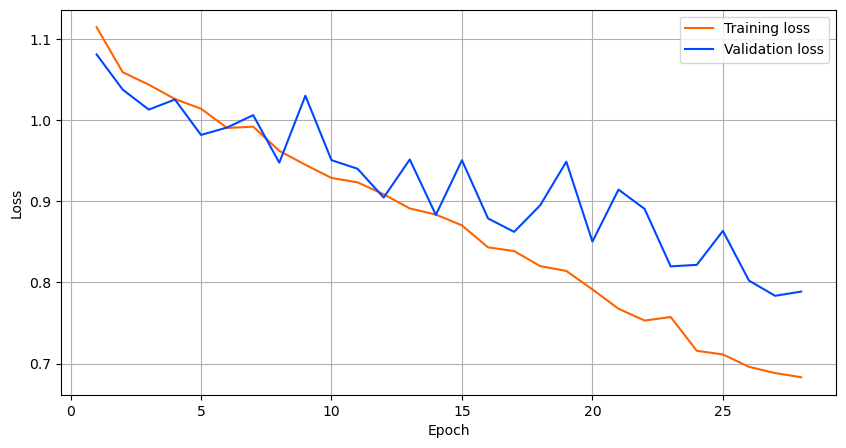

In [35]:
for (i, pipeline) in enumerate(pipelines):
    if (i + 1 == metrics_sorted[0]): visualize_loss(pipeline, save_as=f"loss.png")
    else: visualize_loss(pipeline)

# Confusion Matrix

In [36]:
def confusion_matrix(pipeline, X, y, save_as=None):
    y_pred = pipeline.predict(X)
    y_true = list(map(lambda v: v[0], y.values))

    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = mpl.colormaps["Blues"]
    _ = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["Nothing", "Cyclone", "Anticyclone"], normalize="true", colorbar=False, cmap=cmap, ax=ax)

    ax.grid(False)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.yticks(rotation=90, va="center") 

    if (save_as != None): plt.savefig(f"./figures/{save_as}", dpi=200, transparent=True, bbox_inches="tight")
    plt.show()

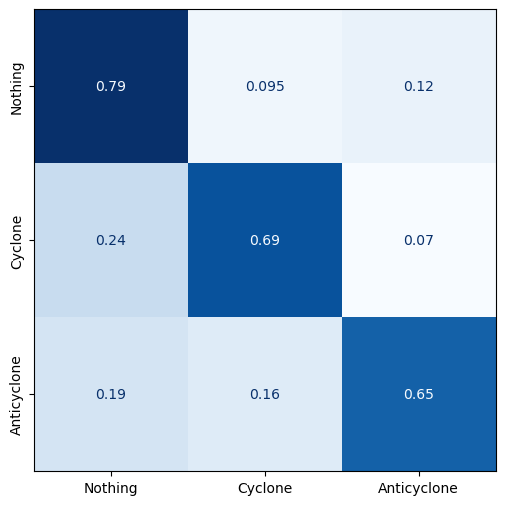

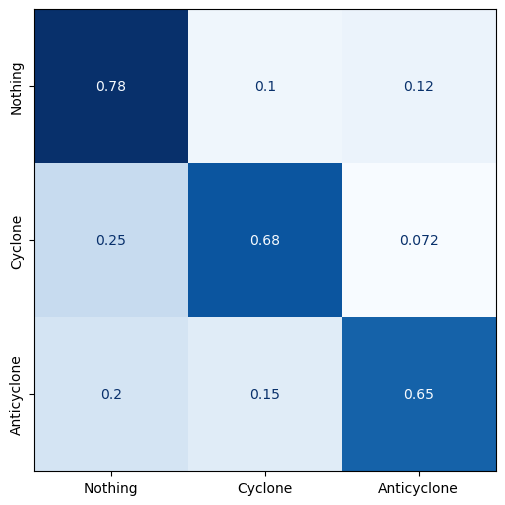

In [37]:
confusion_matrix(metrics_sorted[1], X_train, y_train, save_as="cnn_confusion_matrix_train.png")
confusion_matrix(metrics_sorted[1], X_val, y_val, save_as="cnn_confusion_matrix_val.png")

# Metrics

In [38]:
for (i, _, metrics) in metrics_list:
    print(f"Pipeline {i}:\n{metrics}\n")

Pipeline 1:
Accuracy: 0.70756
Balanced accuracy: 0.70435
Matthews correlation coefficient: 0.56102



# Combining CNN with Random Forest

In [39]:
# Let's try combining the (best) CNN (without the last layer) with a Random Forest Classifier.

def _apply_cnn(data):
    model = pipeline_5.steps[-1][1].module.cls
    model.eval()

    with torch.no_grad():
        return model(data).flatten(start_dim=-3)

t_cnn = FunctionTransformer(func=_apply_cnn)

pipeline_rf = Pipeline([
    ("mask_chla", t_mask_chla),
    ("orientate", t_orientate),
    ("scale", t_scale),
    ("resize", t_resize),
    ("tensors", t_tensors_x),
    ("cnn", t_cnn),
    ("classification", RandomForestClassifier(class_weight="balanced", random_state=seed))
])

filter_index = t_filter_sst.transform(X_train).index

pipeline_rf.fit(
    X_train.drop(index=X_train.index.difference(filter_index)),
    t_tensors_y.transform(y_train.drop(index=y_train.index.difference(filter_index)))
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('mask_chla', ...), ('orientate', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function _ma...x778569d71900>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to

Accuracy: 0.96241
Balanced accuracy: 0.96003
Matthews correlation coefficient: 0.94468


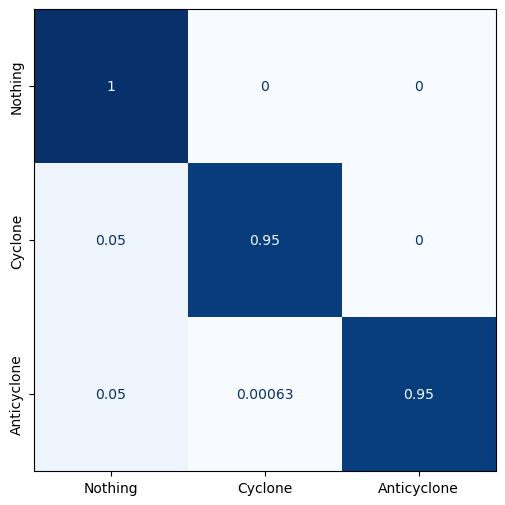

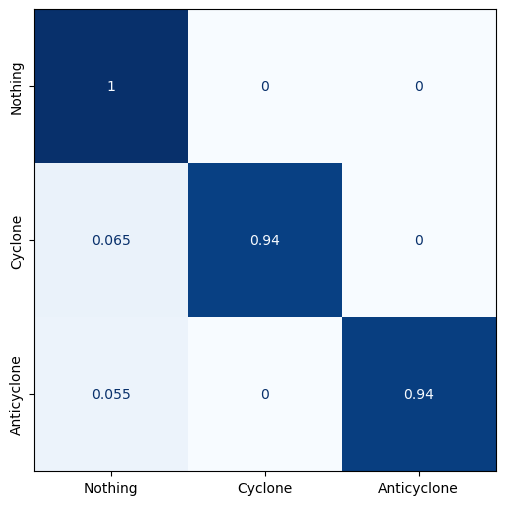

In [40]:
print(f"{Metrics(pipeline_rf, X_val, list(map(lambda v: v[0], y_val.values)))}")
confusion_matrix(pipeline_rf, X_train, y_train, save_as="cnn_rf_confusion_matrix_train.png")
confusion_matrix(pipeline_rf, X_val, y_val, save_as="cnn_rf_confusion_matrix_val.png")

# print(f"\nTest: \n{Metrics(pipeline_rf, X_test, list(map(lambda v: v[0], y_test.values)))}")
# confusion_matrix(pipeline_rf, X_test, y_test)

In [43]:
pipeline_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('mask_chla', ...), ('orientate', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function _ma...x778569d71900>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to

Accuracy: 0.97480
Balanced accuracy: 0.97235
Matthews correlation coefficient: 0.96244


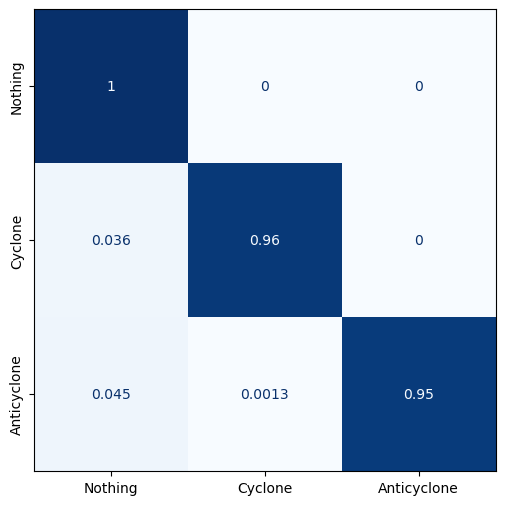

In [42]:
print(f"{Metrics(pipeline_rf, X_test, list(map(lambda v: v[0], y_test.values)))}")
confusion_matrix(pipeline_rf, X_test, y_test, save_as="cnn_rf_confusion_matrix_test.png")

<h1>References</h1>

<p>[1] Dennis G Wilson, Mercator Hackathon, Simon van Gennip, and svangennip. Ocean Eddy Identification. Kaggle. (2022). <a href="https://www.kaggle.com/competitions/mercatorocean" target="_blank">https://www.kaggle.com/competitions/mercatorocean/data</a> (Accessed online: 20.04.2026)</p>